In [1]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import random

print("Hello, World!")
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Hello, World!
NumPy version: 2.2.3
Matplotlib version: 3.10.0


In [11]:
a = np.array(np.arange(10))
print(a)

sizes = [784, 16, 16, 10]
print(sizes[:-1])
print(sizes[1:])
print(list(zip(sizes[:-1], sizes[1:])))

print("Biases:")
for y in sizes[1:]:
    print(np.random.randn(y, 1))

print("Weights:")
for x, y in zip(sizes[:-1], sizes[1:]):
    print(np.random.randn(y, x))




[0 1 2 3 4 5 6 7 8 9]
[784, 16, 16]
[16, 16, 10]
[(784, 16), (16, 16), (16, 10)]
Biases:
[[ 0.58941821]
 [ 1.7630526 ]
 [-0.53882918]
 [-0.0872937 ]
 [-0.08271568]
 [ 0.11597712]
 [ 0.2028127 ]
 [-0.49986495]
 [-1.90730491]
 [-1.83324349]
 [ 0.65832527]
 [-1.28506969]
 [-1.14445364]
 [ 1.34338576]
 [ 0.46900048]
 [-2.62258762]]
[[ 1.93727589]
 [-1.42840774]
 [ 1.25128275]
 [-0.73082131]
 [ 0.66067373]
 [-0.01907683]
 [ 0.68987132]
 [ 0.60245004]
 [-0.01819386]
 [ 0.47056211]
 [ 0.57666021]
 [-0.00254434]
 [-0.1122504 ]
 [-0.41228547]
 [-0.92970337]
 [ 0.28638654]]
[[-0.38125426]
 [ 0.60875959]
 [-0.0347214 ]
 [ 1.57788116]
 [-0.51017649]
 [ 0.15092772]
 [-0.57854346]
 [ 0.17257998]
 [ 0.10962248]
 [ 0.01376057]]
Weights:
[[-0.25931915 -1.01806353 -0.80439543 ...  1.27052708  0.40753903
  -0.90323459]
 [-0.80405434 -0.39471122  1.57953802 ...  0.38189721  1.53068933
  -0.47944397]
 [ 0.65456058  1.27299774  1.46463034 ... -0.59556836 -1.12183063
  -0.69836082]
 ...
 [-0.66075577 -0.4700

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z)*(1-sigmoid(z))

In [15]:
class NeuralNetwork(object):
    def __init__(self, sizes):
        
        """The list ``sizes`` contains the number of neurons in the
        respective layers of the network.  For example, if the list
        was [2, 3, 1] then it would be a three-layer network, with the
        first layer containing 2 neurons, the second layer 3 neurons,
        and the third layer 1 neuron.  The biases and weights for the
        network are initialized randomly, using a Gaussian
        distribution with mean 0, and variance 1.  Note that the first
        layer is assumed to be an input layer, and by convention we
        won't set any biases for those neurons, since biases are only
        ever used in computing the outputs from later layers."""
        
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        # C style for loop to initialize biases, making it more explicit
        # self.biases = []
        # for y in sizes[1:]:
        #     self.biases.append(np.random.randn(y, 1))
            
        self.weights = [np.random.randn(y, x) 
            for x, y in zip(sizes[:-1], sizes[1:])]
        
        # self.weights = []
        # for x, y in zip(sizes[:-1], sizes[1:]):
        #     self.weights.append(np.random.randn(y, x))

    def feed_forward(self, a):
        for layer_idx, (b, w) in enumerate(zip(self.biases, self.weights), start=1):
            # Here b & w are the bias vector and weight matrices for each layer
            in_size = self.sizes[layer_idx - 1]
            out_size = self.sizes[layer_idx]
            # print(f"Layer from {in_size} -> {out_size}")
            # print("Biases:", b)
            # print("Weights:", w)
            z = np.dot(w, a) + b
            a = sigmoid(z)
            # print("Activation:", a)
        return a
    
    def SGD(self, training_data, epochs, mini_batch_size, learning_rate,
            test_data=None):
        """Train the neural network using mini-batch stochastic
        gradient descent.  The ``training_data`` is a list of tuples
        ``(x, y)`` representing the training inputs and the desired
        outputs.  The other non-optional parameters are
        self-explanatory.  If ``test_data`` is provided then the
        network will be evaluated against the test data after each
        epoch, and partial progress printed out.  This is useful for
        tracking progress, but slows things down substantially."""
        n_test = len(test_data) if test_data is not None else None
        n = len(training_data)
        accuracies = []
        for j in range(epochs):
            random.shuffle(training_data)
            mini_batches = [
                training_data[k:k+mini_batch_size]
                for k in range(0, n, mini_batch_size)]
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, learning_rate)
            if test_data is not None:
                metric = self.evaluate(test_data)
                accuracies.append(metric)
                print(f"Epoch {j}: {metric} / {n_test}")
            else:
                print(f"Epoch {j} complete")
        return accuracies
                
    
    
    def update_mini_batch(self, mini_batch, learning_rate):
        """Update the network's weights and biases by applying
        gradient descent using backpropagation to a single mini batch.
        The ``mini_batch`` is a list of tuples ``(x, y)``, and ``learning rate``."""
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.back_prop(x, y)
            nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
        self.weights = [w-(learning_rate/len(mini_batch))*nw
                        for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b-(learning_rate/len(mini_batch))*nb
                       for b, nb in zip(self.biases, nabla_b)]
    
    def back_prop(self, x, y):
        """Return a tuple ``(nabla_b, nabla_w)`` representing the
        gradient for the cost function C_x.  ``nabla_b`` and
        ``nabla_w`` are layer-by-layer lists of numpy arrays, similar
        to ``self.biases`` and ``self.weights``."""
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        
        # feedforward
        activation = x
        activations = [x] # list to store all the activations, layer by layer
        zs = [] # list to store all the z vectors, layer by layer
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation)+b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
        
        # backward pass
        # compute the error at the output layer
        delta = self.cost_derivative(activations[-1], y) * sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].T)
        # here l = 1 means the last layer of neurons, l = 2 is the
        # second-last layer, and so on.
        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            
            # delta is the error term for layer l+1, calculated previously
            # we use it to calculate the error term for layer l i.e. delta1
            delta1 = np.dot(self.weights[-l+1].T, delta) * sp
            
            # update delta to delta1 for next iteration
            delta = delta1
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].T)
        return (nabla_b, nabla_w)
    
    def evaluate(self, test_data):
        """Return the number of test inputs for which the neural
        network outputs the correct result. Note that the neural
        network's output is assumed to be the index of whichever
        neuron in the final layer has the highest activation."""
        test_results = [(np.argmax(self.feed_forward(x)), y)
                        for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)
    
    def cost_derivative(self, output_activations, y):
        """Return the vector of partial derivatives partial C_x
        partial a for the output activations."""
        return (output_activations-y)


In [16]:
import mnist_loader
training_data, validation_data, test_data = mnist_loader.load_data_wrapper()

print("Training data size:", len(training_data))
print("Validation data size:", len(validation_data))
print("Test data size:", len(test_data))

nn = NeuralNetwork([784, 16, 16, 10])

Training data size: 50000
Validation data size: 10000
Test data size: 10000


Epoch 0: 9343 / 10000
Epoch 1: 9312 / 10000
Epoch 2: 9357 / 10000
Epoch 3: 9315 / 10000
Epoch 4: 9374 / 10000
Epoch 5: 9324 / 10000
Epoch 6: 9371 / 10000
Epoch 7: 9326 / 10000
Epoch 8: 9310 / 10000
Epoch 9: 9389 / 10000
Epoch 10: 9282 / 10000
Epoch 11: 9322 / 10000
Epoch 12: 9380 / 10000
Epoch 13: 9385 / 10000
Epoch 14: 9367 / 10000
Epoch 15: 9363 / 10000
Epoch 16: 9354 / 10000
Epoch 17: 9379 / 10000
Epoch 18: 9386 / 10000
Epoch 19: 9300 / 10000


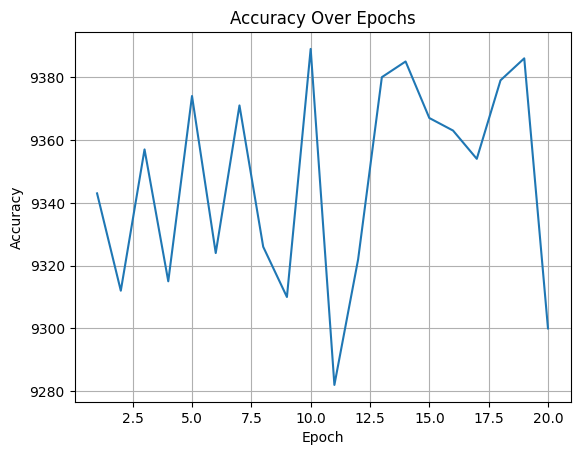

In [22]:
# Train the network using Stochastic Gradient Descent
accuracies = nn.SGD(training_data, epochs=20, mini_batch_size=10, learning_rate=3.0, test_data=test_data)
plt.plot(range(1, len(accuracies)+1), accuracies)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.grid()
plt.show()

In [ ]:

first_input, first_label = training_data[0]
prediction = nn.feed_forward(first_input)
pred_digit = int(np.argmax(prediction))
true_digit = mnist_loader.digit_from_vector(first_label)
cost = np.linalg.norm(prediction - first_label) ** 2
print("Predicted vector:", prediction.T)
print("True label vector:", first_label.T)
print(f"Predicted digit: {pred_digit}")
print(f"True digit: {true_digit}")
print("Cost:", cost)

# b_gradients, w_gradients = nn.back_prop(first_input, first_label)
# print("Bias gradients for each layer:")
# for idx, b_grad in enumerate(b_gradients, start=1):
#     print(f"Layer {idx} bias gradients:\n{b_grad.T}")
# print("Weight gradients for each layer:")
# for idx, w_grad in enumerate(w_gradients, start=1):
#     print(f"Layer {idx} weight gradients:\n{w_grad}")


Predicted vector: [[1.11195545e-05 1.65391212e-02 5.35992505e-03 2.12180354e-05
  8.20965686e-05 3.98289672e-03 9.83565101e-01 2.94124335e-08
  2.06306315e-02 1.98706418e-06]]
True label vector: [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Predicted digit: 6
True digit: 6
Cost: 0.0010138709647300828
Bias gradients for each layer:
Layer 1 bias gradients:
[[-2.21974032e-06  1.03496135e-16  4.54931398e-16 -5.64972080e-07
   0.00000000e+00 -4.34232890e-09  1.40833335e-09 -2.79770655e-11
  -2.39171090e-15  1.29876868e-06 -1.06493735e-17  2.68406941e-18
  -4.69091267e-07  3.11651929e-10 -1.49461252e-10  1.31695412e-17]]
Layer 2 bias gradients:
[[-3.31525121e-04  1.97064397e-04  1.13386367e-06  2.96443866e-04
  -1.04391133e-06  1.16685325e-06 -3.39300430e-10 -2.36501425e-04
  -1.42060322e-07 -1.27012501e-07 -2.93971371e-05 -6.32661522e-05
   1.99928240e-06 -1.15627010e-05  3.25537422e-06 -3.44460559e-09]]
Layer 3 bias gradients:
[[ 1.23643118e-10  2.69018378e-04  2.85748124e-05  4.50195473e-10
   6.7392